# PR11 · Separate geometric unwarping from signal recovery

<!-- paper-first -->
### Research question

**Reading:** [PP01](../../curriculum/papers/processing.md#pp01). Review the assigned figure or result before starting the lesson.

**Question:** Which distortions can a geometric mapping address, and which missing signals can it not recover?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Relate phase-encoding metadata to EPI displacement.
- Distinguish distortion correction from rigid registration.
- Explain why missing signal cannot be restored by coordinate transforms.

## Understand the operation

EPI can be geometrically distorted by off-resonance, particularly near tissue-air boundaries. Much of the displacement occurs along the phase-encoding direction and reverses with its polarity. A rigid transformation cannot generally undo a spatially varying stretch or compression. Field maps or suitable opposing-phase-encoding images add information about this distortion, but their acquisition relationship and metadata must be checked.

A simplified displacement relation is off-resonance in hertz times effective total readout time in seconds, producing a shift in phase-encoding voxels. Sign depends on the image coordinate convention and encoded direction. Total readout time is not TR, TE, or an arbitrary number chosen to make correction run. Conversion tools and BIDS define the metadata you need; vendor-specific derivations require verified acquisition information.

Unwarping changes where measured values are sampled. It cannot recover signal that was lost through intravoxel dephasing, nor does it make every severely compressed region fully informative. Interpolation and any intensity correction have their own effects. Our toy uses a displacement that depends only on the orthogonal coordinate, making its inverse transparent. We create a second image with explicit zeroed signal to show that knowing the exact geometric warp still cannot reconstruct missing information. Opposite-polarity images are useful measurements, but averaging two warped images is not generally equivalent to estimating and applying their correction field.

## Transformation contract

**Input:** EPI-like array, phase-encoding axis/sign and distortion field. **Output:** resampled geometry and QC evidence. **Preserved approximately:** available intensity patterns under interpolation. **Not created:** absent signal. **Toy simplification:** displacement depends on one orthogonal axis, so inverse evaluation is unusually simple.


## Read the actual course material

- [Oxford FSL: Registration practical](https://pages.fmrib.ox.ac.uk/fslcourse/practicals/registration/index.html). Public university practical; linked only, no redistribution license assumed.
- [Oxford FSL: FDT pipeline, TOPUP, EDDY, DTIFIT and TBSS](https://pages.fmrib.ox.ac.uk/fslcourse/practicals/fdt1/index.html). Public university practical; educational data terms at source; linked only.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Explain the units and direction of the synthetic displacement. Compare correct and wrong-sign application. Show why exact geometric knowledge does not restore the deliberately blank region. Never infer missing readout metadata from a desired visual match. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
from scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt
r,c=np.mgrid[:80,:80]; original=np.exp(-((r-40)**2+(c-40)**2)/200)
u=4*np.sin(2*np.pi*c/80)
warped=map_coordinates(original,[r+u,c],order=1,mode='constant')
corrected=map_coordinates(warped,[r-u,c],order=1,mode='constant')
lost=warped.copy(); lost[:,35:45]=0
uncorrectable=map_coordinates(lost,[r-u,c],order=1,mode='constant')
roi=(r>15)&(r<65)&(c>15)&(c<65)
raw_mse=np.mean((warped[roi]-original[roi])**2)
good_mse=np.mean((corrected[roi]-original[roi])**2)
assert good_mse<raw_mse/100 and np.all(uncorrectable[:,35:45]==0)
print('warped/corrected MSE:',raw_mse,good_mse)
print('60Hz × .05s =',60*.05,'PE voxels (sign requires convention)')


warped/corrected MSE: 0.002356755587581355 3.1523463792422675e-07
60Hz × .05s = 3.0 PE voxels (sign requires convention)


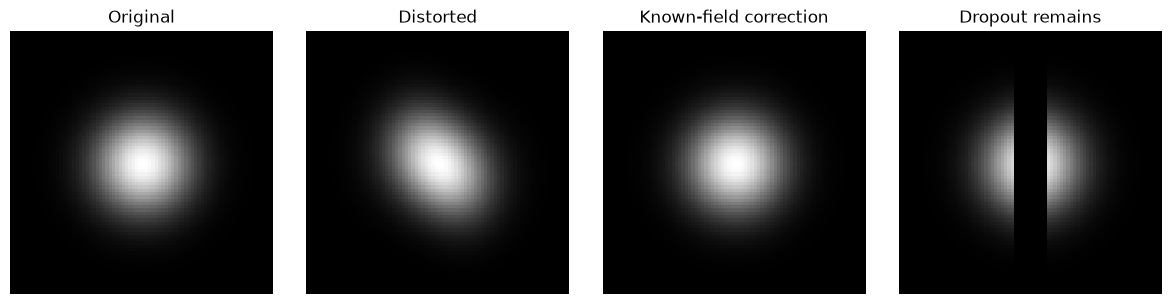

In [2]:
fig,axes=plt.subplots(1,4,figsize=(12,3))
for ax,x,title in zip(axes,[original,warped,corrected,uncorrectable],
                      ['Original','Distorted','Known-field correction','Dropout remains']):
    ax.imshow(x,cmap='gray',vmin=0,vmax=1); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()
wrong=map_coordinates(warped,[r+u,c],order=1,mode='constant')
assert np.mean((wrong[roi]-original[roi])**2)>raw_mse


## Check and explain

The exact known inverse reduces interior geometric MSE by more than100-fold, while the blank column band remains blank. The wrong sign makes the spatial error worse. The three-voxel illustrative shift is a unit calculation, not a recommendation for any scanner.

## Deliberately wrong method

Using TR for total readout time, guessing phase-encoding sign, averaging opposing distorted images as a universal correction, or describing an unwarped dropout region as restored all make different errors. Identify which metadata or missing observation would be needed to resolve each.

## Transfer to an actual dataset or tool — guided assignment

Complete Oxford FDT TOPUP or Registration fieldmap sections. Inspect the actual opposing-polarity images, acquisition-parameter table, units and correspondence to the target run. Compare corrected and uncorrected anatomy using identical cuts, and mark residual dropout separately from distortion. Submit the chosen metadata source and command log. Acquisition-specific settings must come from the dataset and current tool documentation; this notebook intentionally supplies no universal readout constant.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Why can rigid registration leave EPI misaligned locally? **Answer:** distortion is spatially varying, not a single pose change.
2. Can unwarping recreate dephased signal? **Answer:** no; coordinate correction cannot recover information absent from the measurement.


### Return to the research question

Revisit [PP01](../../curriculum/papers/processing.md#pp01) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
